In [3]:
import pandas as pd
import requests as req
import numpy
import matplotlib.pyplot as plt
import statistics
import seaborn as sns
from scipy.stats import kurtosis
from azure.storage.blob import BlobClient, BlobType, BlobServiceClient
from pathlib import Path
import os
# from statsmodels.tsa.stattools import adfuller
# from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# from statsmodels.tsa.arima.model import ARIMA
# from pyspark.sql import SparkSession
from datetime import datetime

In [23]:
from_date = input("enter from year and month hypen separated:")
to_date = input("enter to year and month hypen separated:")
country_code = input("enter three letter country code in capital")

power_generation_url = f"https://api.ember-energy.org/v1/electricity-generation/monthly?entity_code={country_code}&is_aggregate_entity=false&start_date={from_date}&end_date={to_date}&is_aggregate_series=false&include_all_dates_value_range=false&api_key=d990ce99-beb8-3f09-c7cc-3ed2c5eb7c8e"
json_repsonse = req.get(power_generation_url)
print(json_repsonse.json()['data'])
power_df = pd.DataFrame(json_repsonse.json()['data'])
# power_df['updated_on'] = pd.to_datetime(power_df['updated_on'], unit='ms')
print(power_df[['entity', 'entity_code', 'date', 'series', 'generation_twh']])
power_source = input("Enter source of power: ")
print(type(json_repsonse))

[{'entity': 'India', 'entity_code': 'IND', 'is_aggregate_entity': False, 'date': '2020-01-01', 'series': 'Bioenergy', 'is_aggregate_series': False, 'generation_twh': 2.18, 'share_of_generation_pct': 1.91}, {'entity': 'India', 'entity_code': 'IND', 'is_aggregate_entity': False, 'date': '2020-01-01', 'series': 'Coal', 'is_aggregate_series': False, 'generation_twh': 87.4, 'share_of_generation_pct': 76.75}, {'entity': 'India', 'entity_code': 'IND', 'is_aggregate_entity': False, 'date': '2020-01-01', 'series': 'Gas', 'is_aggregate_series': False, 'generation_twh': 3.39, 'share_of_generation_pct': 2.98}, {'entity': 'India', 'entity_code': 'IND', 'is_aggregate_entity': False, 'date': '2020-01-01', 'series': 'Hydro', 'is_aggregate_series': False, 'generation_twh': 9.23, 'share_of_generation_pct': 8.1}, {'entity': 'India', 'entity_code': 'IND', 'is_aggregate_entity': False, 'date': '2020-01-01', 'series': 'Net imports', 'is_aggregate_series': False, 'generation_twh': -0.46, 'share_of_generation

In [24]:
start_time = datetime.now()
power_source_df = power_df.loc[(power_df['series'] == power_source) & (power_df['generation_twh'] != 0)]
print(power_source_df[['entity', 'entity_code', 'date', 'series', 'generation_twh']])

    entity entity_code        date series  generation_twh
9    India         IND  2020-01-01   Wind            3.32
19   India         IND  2020-02-01   Wind            3.52
29   India         IND  2020-03-01   Wind            3.40
39   India         IND  2020-04-01   Wind            3.47
49   India         IND  2020-05-01   Wind            6.24
59   India         IND  2020-06-01   Wind            7.90
69   India         IND  2020-07-01   Wind            6.97
79   India         IND  2020-08-01   Wind            9.65
89   India         IND  2020-09-01   Wind            4.85
99   India         IND  2020-10-01   Wind            3.99
109  India         IND  2020-11-01   Wind            3.31
119  India         IND  2020-12-01   Wind            3.82
129  India         IND  2021-01-01   Wind            3.56
139  India         IND  2021-02-01   Wind            2.87
149  India         IND  2021-03-01   Wind            3.53
159  India         IND  2021-04-01   Wind            3.73
169  India    

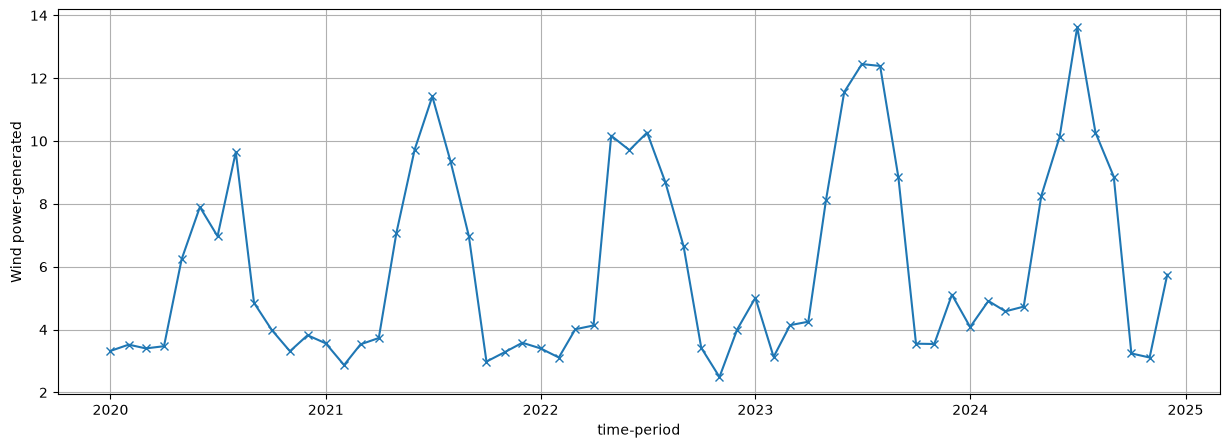

In [25]:
power_gen_fig = plt.figure()
power_gen_fig.set_figwidth(15)
power_gen_fig.set_figheight(5)

x_axis_points = numpy.array(pd.DatetimeIndex(power_source_df['date']))
y_axis_points = numpy.array(power_source_df['generation_twh'])

plt.xlabel('time-period')
plt.ylabel(power_source+' power-generated')

# plt.bar(x_axis_points, y_axis_points, color="green")
plt.plot(x_axis_points, y_axis_points, marker = 'x')
plt.grid()


In [26]:
year_set = set()
for row in power_source_df.iterrows():
    year_set.update(pd.DatetimeIndex(power_source_df['date']).year)

yr_mm_dict = dict()

for i in year_set:
    mm_ls = list() 
    for date_val in power_source_df['date']:        
        if(pd.Timestamp(date_val).year == i):            
            mm_ls.append(pd.Timestamp(date_val).month)        
    yr_mm_dict[i] = mm_ls

print(yr_mm_dict)
print(year_set)
power_df.head()

# print(year_set)
# print(power_source_df.groupby([pd.DatetimeIndex(power_df['date']).year, power_df['series']])['generation_twh'].sum())
    

{2020: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], 2021: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], 2022: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], 2023: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], 2024: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]}
{2020, 2021, 2022, 2023, 2024}


,entity,entity_code,is_aggregate_entity,date,series,is_aggregate_series,generation_twh,share_of_generation_pct
0,India,IND,False,2020-01-01,Bioenergy,False,2.18,1.91
1,India,IND,False,2020-01-01,Coal,False,87.40,76.75
2,India,IND,False,2020-01-01,Gas,False,3.39,2.98
3,India,IND,False,2020-01-01,Hydro,False,9.23,8.10
4,India,IND,False,2020-01-01,Net imports,False,-0.46,-0.40


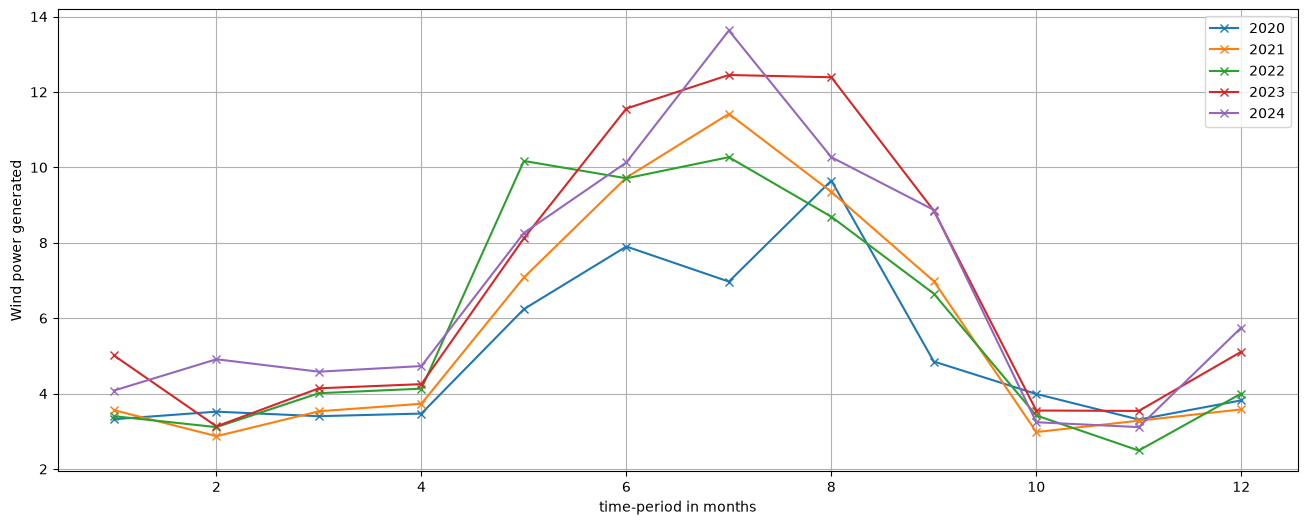

In [27]:
power_gen_fig = plt.figure()
power_gen_fig.set_figwidth(16)
power_gen_fig.set_figheight(6)

plt.grid()

plt.xlabel("time-period in months")
plt.ylabel(power_source+ " power generated")


for yr in year_set:
    power_source_df = power_df.loc[(power_df['series'] == power_source) & (power_df['generation_twh'] != 0) & (pd.DatetimeIndex(power_df['date']).year == yr)]
    power_source_df[['date','series', 'generation_twh']].head()
    x_axis_points = numpy.array(pd.DatetimeIndex(power_source_df['date']).month)
    y_axis_points = numpy.array(power_source_df['generation_twh'])
    plt.plot(x_axis_points, y_axis_points, marker = 'x', label=str(yr))
    plt.legend()

Standard Deviation =  2.14560156147549
Mean =  5.036666666666667
Variance =  4.603606060606061
Standard Deviation =  3.0858046197896507
Mean =  5.674166666666666
Variance =  9.522190151515153
Standard Deviation =  3.049191025352611
Mean =  5.8375
Variance =  9.29756590909091
Standard Deviation =  3.6437938104856227
Mean =  6.841666666666667
Variance =  13.277233333333333
Standard Deviation =  3.3543874480320772
Mean =  6.796666666666667
Variance =  11.251915151515153


<Figure size 1600x600 with 0 Axes>

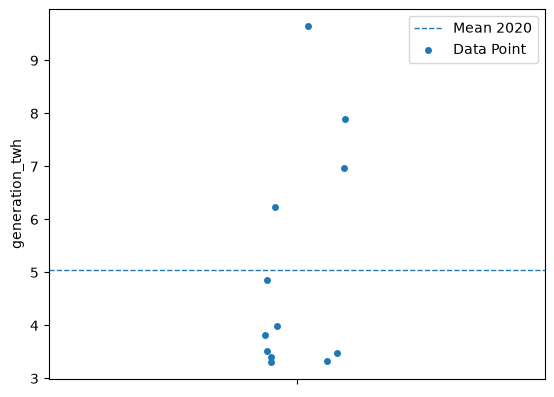

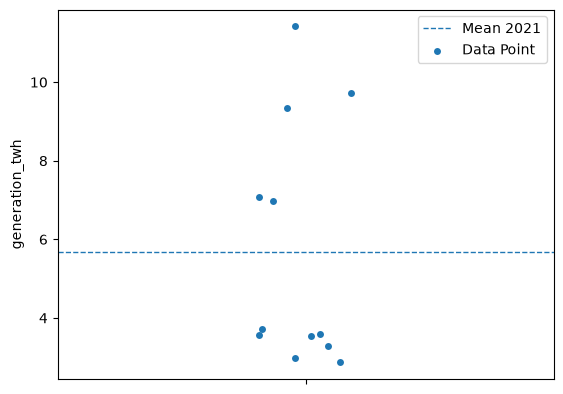

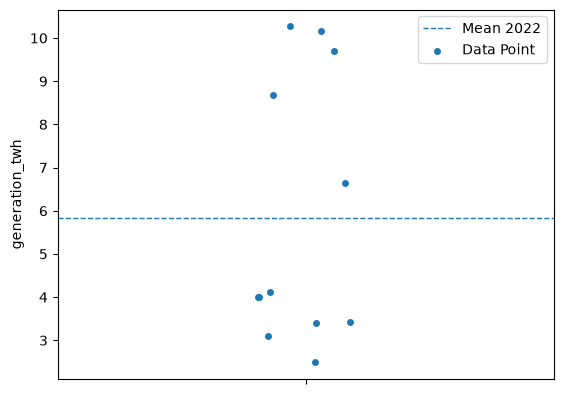

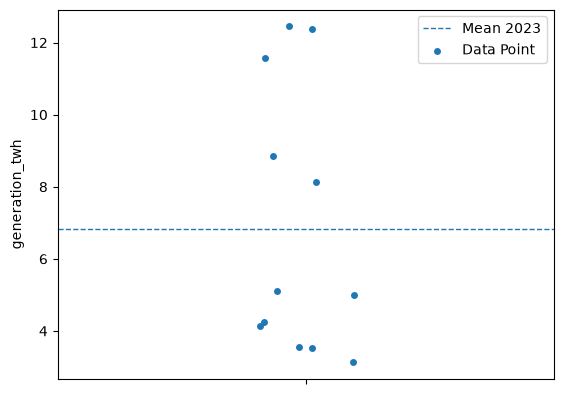

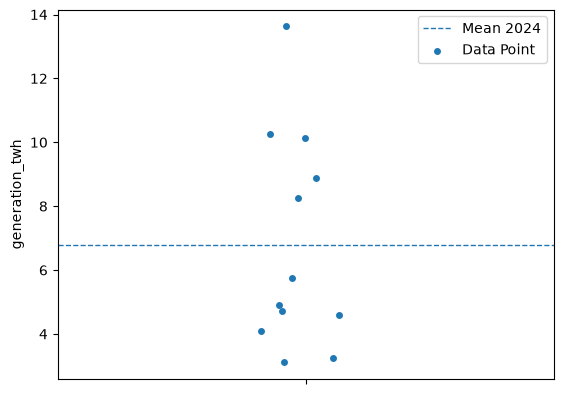

In [28]:
current_power_source = pd.DataFrame()

power_gen_fig = plt.figure()
power_gen_fig.set_figwidth(16)
power_gen_fig.set_figheight(6)

def create_plots(mn, yr):
    plt.figure()
    plt.axhline(mn, linestyle='dashed', linewidth=1, label ='Mean '+str(yr))    
    sns.stripplot(current_power_source['generation_twh'], label = "Data Point")         
    plt.legend()

for y in year_set:
    current_power_source = power_df.loc[(power_df['series'] == power_source) & (power_df['generation_twh'] != 0) & (pd.DatetimeIndex(power_df['date']).year == y)]
    print("Standard Deviation = ",statistics.stdev(current_power_source['generation_twh']))
    print("Mean = ",statistics.mean(current_power_source['generation_twh']))
    print("Variance = ", statistics.variance(current_power_source['generation_twh']))
    std_dev = statistics.stdev(current_power_source['generation_twh'])
    mn = statistics.mean(current_power_source['generation_twh'])
    var = statistics.variance(current_power_source['generation_twh'])
    create_plots(mn, y)   


[3.31, 3.32, 3.4, 3.47, 3.52, 3.82, 3.99, 4.85, 6.24, 6.97, 7.9, 9.65]
median =  3.9050000000000002
Q1 =  3.4525
Q2 =  3.9050000000000002
Q3 =  6.4225
[2.87, 2.98, 3.28, 3.53, 3.56, 3.58, 3.73, 6.98, 7.08, 9.35, 9.73, 11.42]
median =  3.6550000000000002
Q1 =  3.4675
Q2 =  3.6550000000000002
Q3 =  7.6475
[2.49, 3.11, 3.4, 3.42, 4.0, 4.01, 4.13, 6.65, 8.69, 9.71, 10.17, 10.27]
median =  4.07
Q1 =  3.415
Q2 =  4.07
Q3 =  8.945
[3.13, 3.54, 3.55, 4.14, 4.25, 5.01, 5.11, 8.12, 8.85, 11.56, 12.39, 12.45]
median =  5.0600000000000005
Q1 =  3.9924999999999997
Q2 =  5.0600000000000005
Q3 =  9.5275
[3.11, 3.24, 4.08, 4.58, 4.73, 4.91, 5.75, 8.26, 8.87, 10.13, 10.27, 13.63]
median =  5.33
Q1 =  4.455
Q2 =  5.33
Q3 =  9.184999999999999


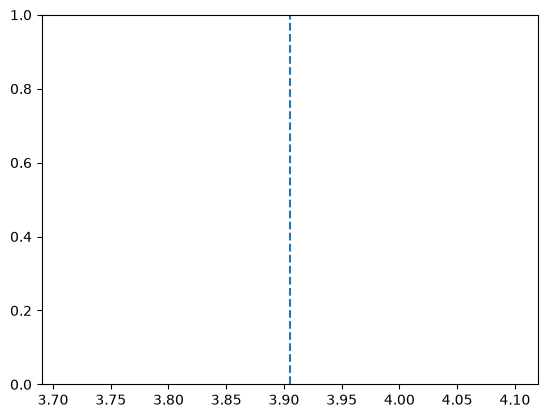

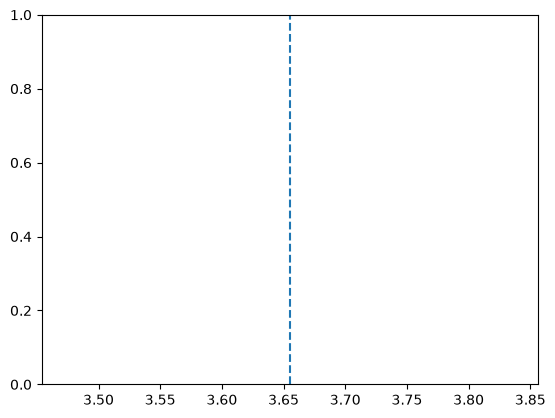

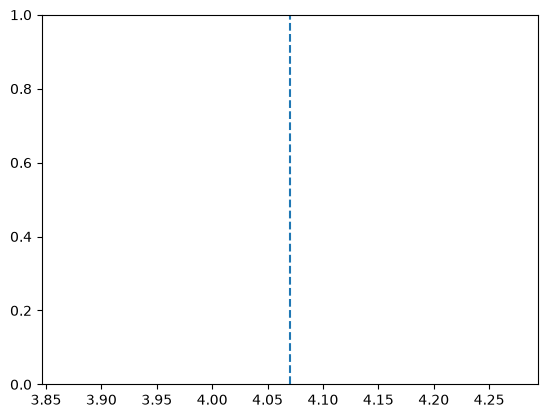

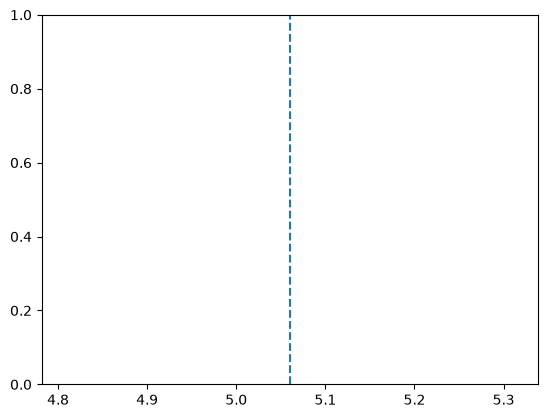

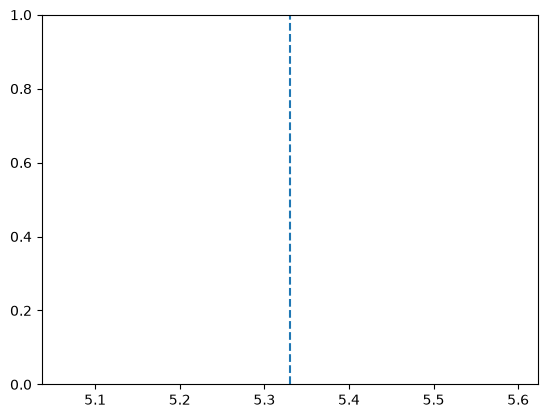

In [29]:
# print(current_power_source)
for y in year_set:
    df = power_df.loc[(power_source == power_df['series']) & (power_df['generation_twh'] != 0) & (pd.DatetimeIndex(power_df['date']).year == y)]
    print(sorted(df['generation_twh']))
    med = statistics.median(sorted(df['generation_twh']))
    print("median = ", med)

    q_1 = numpy.quantile(df['generation_twh'], 0.25)
    q_2 = numpy.quantile(df['generation_twh'], 0.50)
    q_3 = numpy.quantile(df['generation_twh'], 0.75)

    print("Q1 = ", q_1)
    print("Q2 = ", q_2)
    print("Q3 = ", q_3)
    
    plt.figure()
    plt.axvline(med,linestyle="dashed")    

In [21]:
file_path = "E:\\India-Power-Capacity-DE\\"

for yr in year_set:
    df = power_df.loc[(power_source == power_df['series']) & (power_df['generation_twh'] != 0) & (pd.DatetimeIndex(power_df['date']).year == yr)]
    print(df[['series', 'generation_twh', 'date']])
    f = open(file_path+power_source+"_power_generated"+"_"+str(yr),'a')
    df[['series', 'generation_twh', 'date']].to_csv(file_path+power_source+"_power_generated"+"_"+str(yr), index=False)
    f.close()
    file_name = power_source+"_power_generated"+"_"+str(yr)
    conn_string = ""
    # blb_service_client = BlobServiceClient.from_connection_string(conn_string)
    # container_client_obj = blb_service_client.get_container_client("yearly-power-generation")
    # with open(file = os.path.join("E:\\India-Power-Capacity-DE",file_name), mode="rb") as data:
    #     container_client_obj.upload_blob(name=file_name, data=data, overwrite=True)
    end_time = datetime.now()
    time_diff = (end_time-start_time).total_seconds()
    print(time_diff)
    # file_upload(power_source+"_power_generated"+"_"+str(yr))
    # with open(file_path+power_source+"_power_generated"+"_"+str(yr), 'a') as f:
        # df.to_csv()

    series  generation_twh        date
1     Coal           86.37  2019-01-01
11    Coal           78.20  2019-02-01
21    Coal           91.30  2019-03-01
31    Coal           90.44  2019-04-01
41    Coal           94.37  2019-05-01
51    Coal           89.88  2019-06-01
61    Coal           83.20  2019-07-01
71    Coal           76.83  2019-08-01
81    Coal           74.60  2019-09-01
91    Coal           74.86  2019-10-01
101   Coal           75.72  2019-11-01
111   Coal           82.77  2019-12-01
5.182061
    series  generation_twh        date
121   Coal           87.40  2020-01-01
131   Coal           85.62  2020-02-01
141   Coal           78.50  2020-03-01
151   Coal           61.94  2020-04-01
161   Coal           72.66  2020-05-01
171   Coal           73.06  2020-06-01
181   Coal           80.58  2020-07-01
191   Coal           74.69  2020-08-01
201   Coal           81.58  2020-09-01
211   Coal           84.89  2020-10-01
221   Coal           78.71  2020-11-01
231   Coal      

In [31]:
power_sector_emissions_url = f"https://api.ember-energy.org/v1/power-sector-emissions/monthly?entity_code={country_code}&is_aggregate_entity=false&start_date={from_date}&end_date={to_date}&series={power_source}&is_aggregate_series=false&include_all_dates_value_range=false&api_key=d990ce99-beb8-3f09-c7cc-3ed2c5eb7c8e"
emission_api_response = req.get(power_sector_emissions_url).json()
emissions_df = pd.DataFrame(emission_api_response['data'])
emissions_df.merge(power_df, how="inner").head()

,entity,entity_code,is_aggregate_entity,date,series,is_aggregate_series,emissions_mtco2,share_of_emissions_pct,generation_twh,share_of_generation_pct
0,India,IND,False,2020-01-01,Wind,False,0.05,0.06,3.32,2.92
1,India,IND,False,2020-02-01,Wind,False,0.06,0.07,3.52,3.13
2,India,IND,False,2020-03-01,Wind,False,0.06,0.07,3.40,3.16
3,India,IND,False,2020-04-01,Wind,False,0.06,0.09,3.47,3.78
4,India,IND,False,2020-05-01,Wind,False,0.10,0.14,6.24,5.69


    entity entity_code  is_aggregate_entity        date series  \
9    India         IND                False  2020-01-01   Wind   
19   India         IND                False  2020-02-01   Wind   
29   India         IND                False  2020-03-01   Wind   
39   India         IND                False  2020-04-01   Wind   
49   India         IND                False  2020-05-01   Wind   
59   India         IND                False  2020-06-01   Wind   
69   India         IND                False  2020-07-01   Wind   
79   India         IND                False  2020-08-01   Wind   
89   India         IND                False  2020-09-01   Wind   
99   India         IND                False  2020-10-01   Wind   
109  India         IND                False  2020-11-01   Wind   
119  India         IND                False  2020-12-01   Wind   

     is_aggregate_series  generation_twh  share_of_generation_pct  
9                  False            3.32                     2.92  
19   

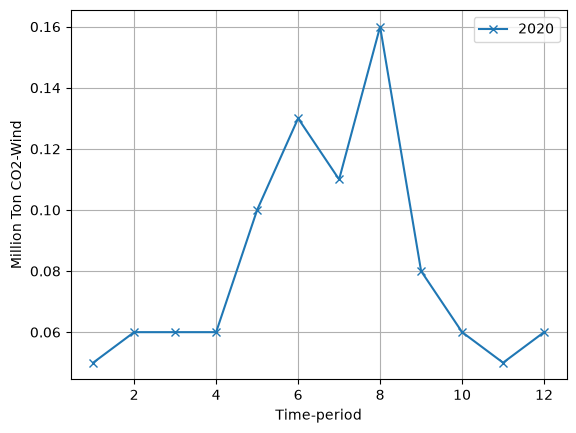

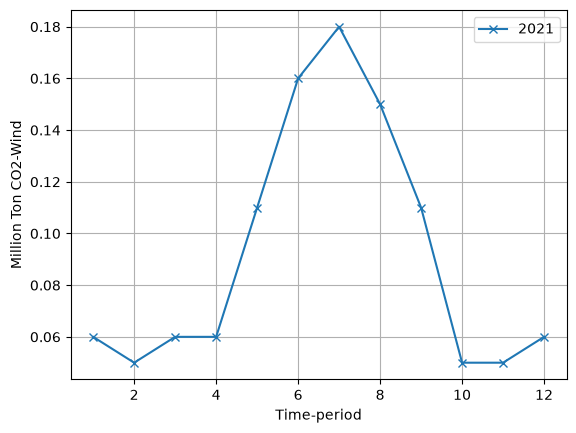

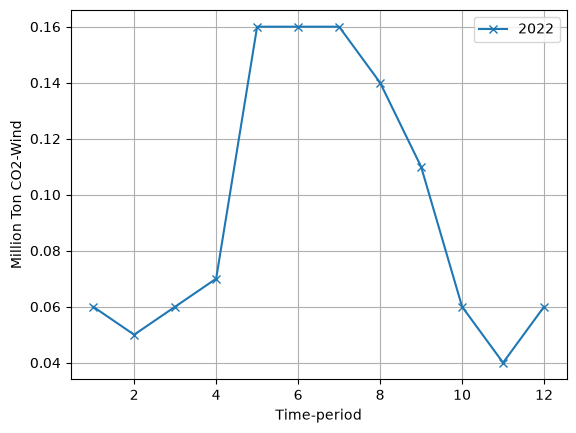

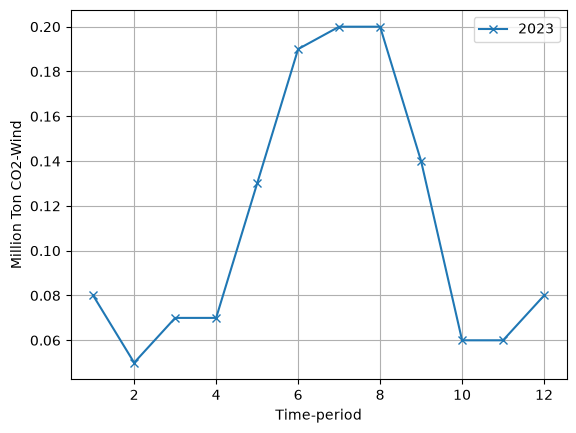

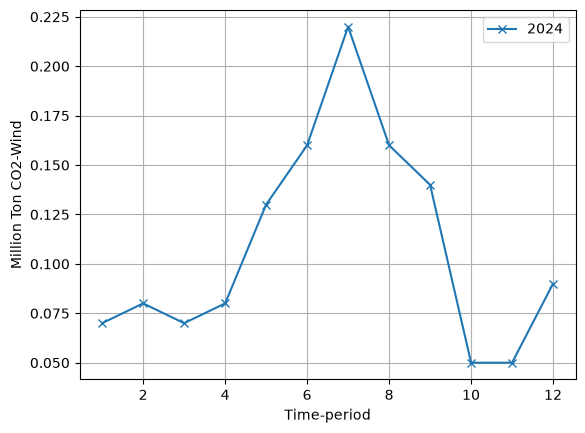

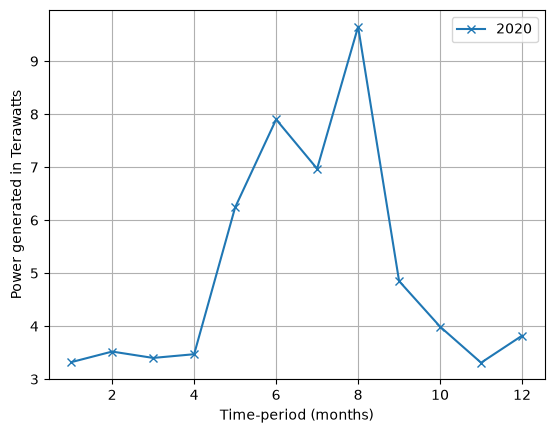

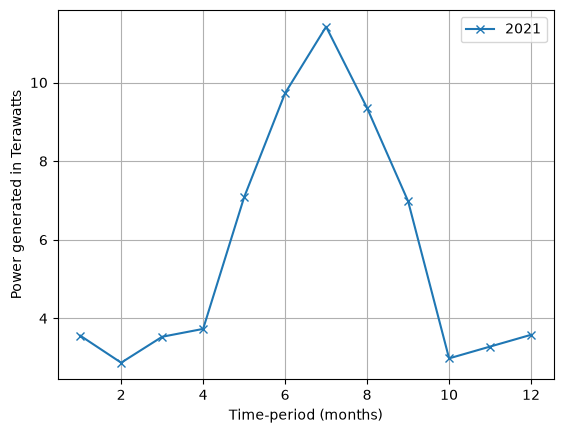

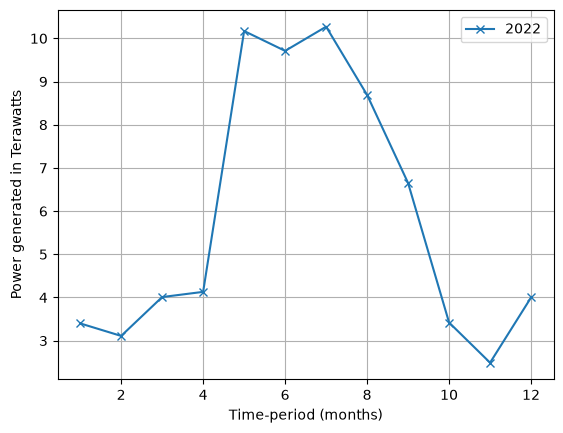

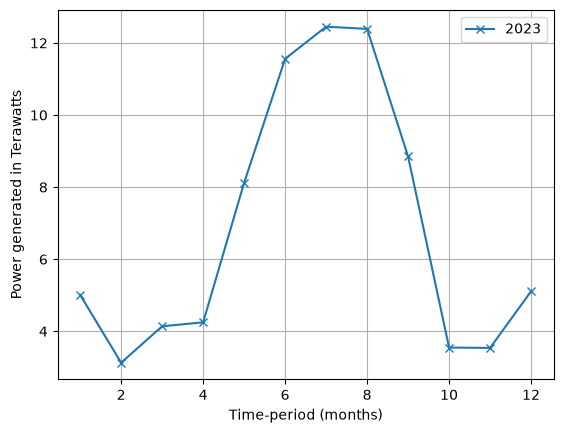

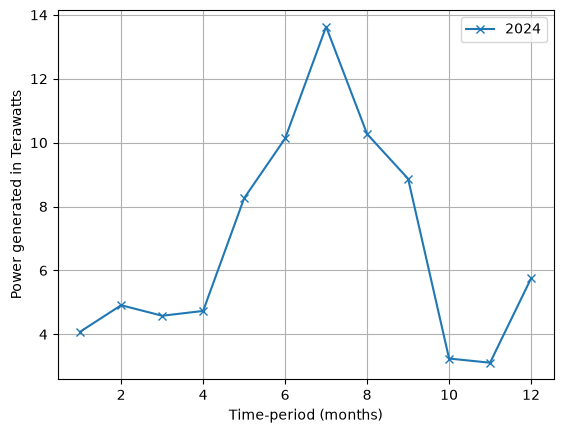

In [ ]:
# emission_fig = plt.figure()

for y in year_set:
    plt.figure()   
    yearly_emission_df = emissions_df.loc[(pd.DatetimeIndex(emissions_df['date']).year == y)]
    x_axis_points = numpy.array(pd.DatetimeIndex(yearly_emission_df['date']).month)
    y_axis_points = numpy.array(yearly_emission_df['emissions_mtco2'])    
    plt.plot(x_axis_points, y_axis_points, label = str(y), marker = 'x')
    plt.xlabel("Time-period")
    plt.ylabel("Million Ton CO2-"+power_source)
    plt.grid()
    plt.legend()

for y in year_set:    
    plt.figure()

    df = power_df.loc[(pd.DatetimeIndex(power_df['date']).year == y) & (power_df['series'] == power_source)]    
    x_axis_points = numpy.array(pd.DatetimeIndex(df['date']).month)
    y_axis_points = numpy.array(df['generation_twh'])
    
    plt.plot(x_axis_points, y_axis_points, marker = 'x', label=str(y))
    plt.xlabel("Time-period (months)")
    plt.ylabel("Power generated in Terawatts")
    plt.grid()
    plt.legend()
# plt.plot(power_df['generation_twh'])

In [22]:
# training_power_source = power_df.loc[(power_df['generation_twh'] != 0) & (power_df['series'] == power_source)]
# training_power_source
# energy_model = ARIMA(training_power_source['generation_twh'], order=(4,3,1))
# model_fit= energy_model.fit()
# print(model_fit.forecast(steps=5))

# coal_data = training_power_source[training_power_source["series"] == "Coal"]
# print(coal_data.tail())

In [23]:
# gas_power_generation_2023 = power_df[(power_df['series'] == 'Gas') & (power_df['generation_twh'] != 0) & (pd.DatetimeIndex(power_df['date']).year == 2023)]
# # print(gas_power_generation_2023['generation_twh'])
# gas_power_mean_2023 = statistics.mean(gas_power_generation_2023['generation_twh'])
# gas_power_median_2023 = statistics.median(sorted(gas_power_generation_2023['generation_twh']))
# gas_power_mode_2023 = statistics.mode(sorted(gas_power_generation_2023['generation_twh']))

# print(gas_power_mean_2023)
# print(gas_power_median_2023)
# print(gas_power_mode_2023)


# sns.kdeplot(gas_power_generation_2023['generation_twh'])
# plt.axvline(gas_power_mean_2023, label="Mean", color="red")
# plt.axvline(gas_power_median_2023, label = "Median", color="yellow")
# plt.axvline(gas_power_mode_2023, label = "Mode")
# plt.grid()
# plt.show()


In [24]:
# print(gas_df[['date', 'generation_twh']])
# print("Gas Year Wise generation")
# print(gas_df.groupby(pd.DatetimeIndex(gas_df['date']).year)['generation_twh'].sum())

# print("\n")

# print("Coal power year wise Generation")
# print(thermal_df.groupby(pd.DatetimeIndex(thermal_df['date']).year)['generation_twh'].sum())

# print("\n")

# print("Wind energy year wise generation")
# print(wind_df.groupby(pd.DatetimeIndex(wind_df['date']).year)['generation_twh'].sum())

# print("\n")
# print("Solar power generation year wise")
# print(solar_df.groupby(pd.DatetimeIndex(solar_df['date']).year)['generation_twh'].sum())

# date_df = pd.DatetimeIndex(power_df['date']).year
# print(date_df)
# series_df = power_df['series'].unique()

# print(power_df.groupby([pd.DatetimeIndex(power_df['date']).year, power_df['series']])['generation_twh'].sum())


In [25]:
# kurtosis(gas_power_generation_2023['generation_twh'] ,axis = 0, fisher=True, bias=True)

# gas_power_generation_2024 = power_df[(power_df['series'] == 'Gas') & (power_df['generation_twh'] != 0) & (pd.DatetimeIndex(power_df['date']).year == 2024)]
# kurtosis(gas_power_generation_2024['generation_twh'])

In [26]:
# gas_power_generation_2025 = power_df[(power_df['series'] == 'Gas') & (power_df['generation_twh'] != 0) & (pd.DatetimeIndex(power_df['date']).year == 2025)]
# gas_power_generation_2024 = power_df[(power_df['series'] == 'Gas') & (power_df['generation_twh'] != 0) & (pd.DatetimeIndex(power_df['date']).year == 2024)]
# gas_power_generation_2023 = power_df[(power_df['series'] == 'Gas') & (power_df['generation_twh'] != 0) & (pd.DatetimeIndex(power_df['date']).year == 2023)]

# print(kurtosis(gas_power_generation_2025['generation_twh']))
# print(kurtosis(gas_power_generation_2024['generation_twh']))
# print(kurtosis(gas_power_generation_2023['generation_twh']))

In [27]:
# sns.kdeplot(gas_power_generation_2025['generation_twh'], color="black")
# sns.kdeplot(gas_power_generation_2024['generation_twh'], color = "blue")
# sns.kdeplot(gas_power_generation_2023['generation_twh'], color= "green")
# plt.grid()

In [28]:
# def file_upload(file_name):
#     conn_string = "DefaultEndpointsProtocol=https;AccountName=indiapowerdata;AccountKey=Ngjt3Jhf8cTrB/OUXVIYP2tCdfhRqmhkZSKKMxyqVuddOKb+TOQ9kqpk5qri/WyprdcUoMiUgphh+AStUgpfSQ==;EndpointSuffix=core.windows.net"
#     blb_service_client = BlobServiceClient.from_connection_string(conn_string)
#     container_client_obj = blb_service_client.get_container_client("yearly-power-generation")
#     with open(file = os.path.join("E:\\India-Power-Capacity-DE",file_name), mode="rb") as data:
        # container_client_obj.upload_blob(name=file_name, data=data, overwrite=False)

In [29]:
# dates = power_source_df['date']
# months = pd.DatetimeIndex(power_source_df['date']).month
# date_df = pd.DataFrame(dates)
# pd.DataFrame(date_df.insert(1, "months",months, allow_duplicates=False))
# print(date_df)

In [30]:
# print(
#     power_df.groupby(
#             [pd.DatetimeIndex(power_df['date']).year, power_df['series']])['generation_twh'].mean())

In [31]:
# sorted_power_df = power_df.sort_values(by='generation_twh', ascending=False)

# # print(sorted_power_df)

# sorted_power_df.loc[sorted_power_df['series'] == 'Coal'].head(3)

In [32]:
# sorted_power_df.groupby([pd.DatetimeIndex(sorted_power_df['date']).year, sorted_power_df['series']])['generation_twh'].sum()
# total_series_gen.max()

In [33]:
# sorted_power_df.groupby([sorted_power_df['series']])['generation_twh'].mean()

In [34]:
# sorted_power_df.groupby([sorted_power_df['series']])['generation_twh'].max()

In [35]:
# sorted_power_df.groupby([sorted_power_df['series']])['generation_twh'].min()

In [36]:
# sorted_power_df

In [37]:
# import sys
# print(sys.executable)
# print(sys.version)

In [38]:
# import sys

# print("Python:", sys.executable)
# print("Spark Python:", spark.sparkContext.getConf().get("spark.pyspark.python"))
# print("Driver Python:", spark.sparkContext.getConf().get("spark.pyspark.driver.python"))

In [39]:
# import sys
# from pyspark.sql import SparkSession

# spark = (
#     SparkSession.builder
#     .master("local[*]")
#     .config("spark.pyspark.python", sys.executable)
#     .config("spark.pyspark.driver.python", sys.executable)
#     .getOrCreate()
# )

# print(spark.sparkContext.getConf().get("spark.pyspark.python"))
# print(spark.sparkContext.getConf().get("spark.pyspark.driver.python"))

In [40]:
# spark.sparkContext._jsc.sc().isStopped()
# spark.sparkContext.getConf().getAll()

In [41]:
# import shutil
# print(shutil.which("python"))